# Fase 2 — Tratamento de dados (SRAG 2023)

O objetivo desta fase é transformar o Parquet bruto (`data/raw/INFLUD23-23-03-2026.parquet`, 279.453 linhas e 194 colunas) em um dataset limpo e tipado (`data/interim/srag_2023_clean.parquet`), pronto para a EDA da Fase 3 e para a feature engineering da Fase 4.

Os inputs são o Parquet bruto e as decisões consolidadas no notebook 01 (drops, filtro temporal, casting, unificação de idade e decodificação de códigos SIVEP-Gripe).

Os outputs são:

- `data/interim/srag_2023_clean.parquet`: dataset completo pós-tratamento, utilizado na EDA e para gerar o dataset de modelagem na Fase 4.
- Figuras de QA em `reports/figures/02_tratamento/`.

O princípio que orienta este notebook é simples: cada decisão de pré-processamento é justificada em um markdown explicativo. A implementação reutilizável vive em `src/maxpar_srag/cleaning.py` (com testes em `tests/test_cleaning.py`); o notebook conta a história e mostra o efeito de cada etapa.

As decisões aplicadas, em resumo, são:

1. Drop de 28 colunas mortas (7 vazias e 21 constantes), sem perda de informação.
2. Filtro temporal `DT_NOTIFIC.year == 2023`, com descarte de 1,1% (3.114 casos fora de escopo).
3. Cast conservador de `object` para numérico (apenas quando 100% dos valores parseiam).
4. `IDADE_ANOS` unificada a partir de `(NU_IDADE_N, TP_IDADE)`, com clip em `[0, 120]`.
5. Binárias `{1, 2, 9}` para `{1, 0, NaN}`.
6. Categóricas multivaloradas ganham coluna `_LABEL` paralela, preservando o código numérico para o modelo.
7. Variáveis derivadas: `FAIXA_ETARIA`, `REGIAO_BR`, `TEMPO_SINTOMA_NOTIF` e `TEMPO_INTERNACAO`.
8. Não há imputação de missing nesta fase. A imputação é responsabilidade da Fase 4, dentro do pipeline ajustável apenas em treino.
9. Não há filtro pelo target nesta fase. O output completo serve à EDA; `clean_pipeline(filter_target=True)` gera o subset de modelagem na Fase 4.

## 1. Setup

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Permite rodar do diretório `notebooks/` sem `pip install -e .`
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from maxpar_srag import cleaning, config
from maxpar_srag.data import load_raw

FIG_DIR = config.FIGURES_DIR / "02_tratamento"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"pandas {pd.__version__} · numpy {np.__version__}")
print(f"PROJECT_ROOT = {config.PROJECT_ROOT}")

pandas 3.0.2 · numpy 2.4.4
PROJECT_ROOT = A:\Repos\Maxpar


## 2. Carregamento do bruto

In [2]:
df = load_raw()
print(f"Shape bruto: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

Shape bruto: 279,453 linhas × 194 colunas


## 3. Drop estrutural — 28 colunas mortas

O profiling da Fase 1 identificou:

- 7 colunas 100% missing (`TABAG`, `DT_RT_VGM`, `PAIS_VGM`, `LO_PS_VGM`, `VG_REINF`, `DT_VGM` e `CO_PS_VGM`), campos do bloco de vigilância genômica e tabagismo que não foram preenchidos em 2023.
- 21 colunas constantes (`HISTO_VGM=0`, `FATOR_RISC=1`, `REINF=2` e blocos `PCR_*` e `AN_*` específicos), sem variância e sem informação a oferecer.

As 5 quase-constantes (`ID_PAIS`, `CO_PAIS`, `POV_CT`, `ESTRANG` e `FAB_RE_BI`) são mantidas porque algumas podem virar binárias úteis na Fase 4 (por exemplo, `ESTRANG` como "é viajante").

Observação sobre `FATOR_RISC=1`: o campo agregador foi marcado em todo registro válido. A informação útil sobre fatores de risco está nos campos individuais (`CARDIOPATI`, `DIABETES`, etc.), e não no agregador.

In [3]:
n_before = df.shape[1]
df = cleaning.drop_dead_columns(df)
print(f"Colunas: {n_before} → {df.shape[1]} (-{n_before - df.shape[1]})")
print(f"Removidas: {sorted(set(cleaning.EMPTY_COLUMNS + cleaning.CONSTANT_COLUMNS))}")

Colunas: 194 → 166 (-28)
Removidas: ['AN_ADENO', 'AN_OUTRO', 'AN_PARA1', 'AN_PARA2', 'AN_PARA3', 'AN_SARS2', 'AN_VSR', 'CO_PS_VGM', 'DT_RT_VGM', 'DT_VGM', 'FATOR_RISC', 'HISTO_VGM', 'LO_PS_VGM', 'PAIS_VGM', 'PCR_ADENO', 'PCR_BOCA', 'PCR_METAP', 'PCR_OUTRO', 'PCR_PARA1', 'PCR_PARA2', 'PCR_PARA3', 'PCR_PARA4', 'PCR_RINO', 'PCR_SARS2', 'PCR_VSR', 'REINF', 'TABAG', 'VG_REINF']


## 4. Cast de dtypes — `object` para numérico onde for seguro

O Parquet bruto saiu da Fase 0 com `infer_schema_length=0` (todas as colunas como string), mas o pyarrow promove parte para `datetime64` na releitura. Sobram cerca de 21 colunas como `object`, em campos numéricos serializados como `Decimal` ou string.

A regra adotada é defensiva: o cast só ocorre em colunas onde todos os valores não nulos parseiam como número. Isso evita destruir silenciosamente colunas que são, de fato, strings (por exemplo, códigos IBGE com letras ou descrições livres).

In [4]:
df = cleaning.cast_dtypes(df)

# Contagem por dtype para auditoria
dtype_counts = df.dtypes.value_counts()
print("Dtypes após cast:")
print(dtype_counts.to_string())

Dtypes após cast:
float64           81
str               54
datetime64[ns]    23
int64              8


## 5. Parse de datas

O filtro temporal exige `DT_NOTIFIC` como `datetime`. A maioria das colunas em `DATE_COLUMNS` já vem parseada pelo pyarrow, mas algumas (em especial `DT_NOTIFIC`) ainda chegam como string no formato `dd/mm/aaaa`. A função é idempotente: pula colunas que já são datetime.

In [5]:
df = cleaning.parse_dates(df)

date_cols_present = [c for c in config.DATE_COLUMNS if c in df.columns]
n_datetime = sum(pd.api.types.is_datetime64_any_dtype(df[c]) for c in date_cols_present)
print(f"Colunas-data presentes : {len(date_cols_present)}")
print(f"Parseadas como datetime: {n_datetime}")
print(f"Range DT_NOTIFIC       : {df['DT_NOTIFIC'].min()} → {df['DT_NOTIFIC'].max()}")

Colunas-data presentes : 30
Parseadas como datetime: 30
Range DT_NOTIFIC       : 2023-01-01 00:00:00 → 2025-06-23 00:00:00


## 6. Filtro temporal — manter apenas 2023

O profiling mostrou que o Parquet bruto contém casos até 2025-06-23 (3.114 casos, ou 1,1%, fora do escopo). O desafio trata explicitamente de 2023. Misturar anos contaminaria a sazonalidade e a distribuição da variável-alvo.

In [6]:
n_before = len(df)
df = cleaning.filter_temporal(df, year=2023)
n_after = len(df)
print(f"Linhas: {n_before:,} → {n_after:,} (-{n_before - n_after:,}, {(n_before - n_after) / n_before * 100:.2f}%)")
print(f"Anos restantes: {sorted(df['DT_NOTIFIC'].dt.year.unique().tolist())}")

Linhas: 279,453 → 276,339 (-3,114, 1.11%)
Anos restantes: [2023]


## 7. Unificação de idade — `IDADE_ANOS`

`NU_IDADE_N` carrega o valor numérico e `TP_IDADE` define a unidade (1=dia, 2=mês, 3=ano). Sem unificação, qualquer agregação por idade fica incorreta para lactentes e neonatos.

É aplicado clip em `[0, 120]`: a base contém registros aberrantes (idade negativa em meses, 999 anos), que correspondem a erros de digitação e são convertidos em NaN.

Vale destacar, para a Fase 3, que a base 2023 tem perfil bimodal (lactentes com menos de 2 anos por VSR pediátrico e idosos por COVID e Influenza). A mediana baixa não é bug; é a realidade epidemiológica do ano.

In [7]:
df = cleaning.unify_age(df)

print("Distribuição original por unidade (TP_IDADE):")
print(pd.to_numeric(df['TP_IDADE'], errors='coerce').value_counts().sort_index().to_string())
print()
print("IDADE_ANOS:")
print(df['IDADE_ANOS'].describe().round(2).to_string())
print(f"NaN após clip [0, 120]: {df['IDADE_ANOS'].isna().sum():,}")

Distribuição original por unidade (TP_IDADE):
TP_IDADE
1      3330
2     62322
3    210687

IDADE_ANOS:
count    276332.0
mean        31.11
std         34.07
min           0.0
25%           1.0
50%           8.0
75%          67.0
max         117.0
NaN após clip [0, 120]: 7


## 8. Decodificação de binárias — `{1, 2, 9}` para `{1, 0, NaN}`

Modelos consomem 0 ou 1. O código `9 = Ignorado` é semanticamente missing; tratá-lo como categoria (por exemplo, 9.0 em um modelo numérico) seria pior do que NaN, pois introduziria viés artificial.

`SUPORT_VEN` não está em `BINARY_FIELDS`: tem 3 valores válidos (1=invasivo, 2=não invasivo, 3=não) e passa pelo decode categórico.

In [8]:
df = cleaning.decode_binary_fields(df)

# Sanity em algumas binárias-chave
amostra_bin = ["FEBRE", "TOSSE", "DIABETES", "CARDIOPATI", "OBESIDADE", "VACINA_COV"]
print("Distribuição pós-decodificação (1=Sim, 0=Não, NaN=Ignorado/missing):")
for col in amostra_bin:
    if col in df.columns:
        vc = df[col].value_counts(dropna=False).to_dict()
        print(f"  {col:12s}: {vc}")

Distribuição pós-decodificação (1=Sim, 0=Não, NaN=Ignorado/missing):
  FEBRE       : {np.float64(1.0): 157302, np.float64(0.0): 78575, <NA>: 40462}
  TOSSE       : {np.float64(1.0): 207090, np.float64(0.0): 43146, <NA>: 26103}
  DIABETES    : {<NA>: 188313, np.float64(0.0): 59744, np.float64(1.0): 28282}
  CARDIOPATI  : {<NA>: 182832, np.float64(0.0): 47593, np.float64(1.0): 45914}
  OBESIDADE   : {<NA>: 197753, np.float64(0.0): 72478, np.float64(1.0): 6108}
  VACINA_COV  : {np.float64(1.0): 142951, np.float64(0.0): 128640, <NA>: 4748}


## 9. Decodificação de categóricas — coluna `_LABEL` paralela

Modelos esperam o código (`CLASSI_FIN ∈ {1..5}`), enquanto humanos e gráficos esperam o rótulo (por exemplo, "SRAG por COVID-19"). Manter os dois lado a lado evita o bug clássico de "perdi o código quando virei tudo string para o gráfico".

Códigos não mapeados viram NaN no `_LABEL`, sinalizando que o dicionário pode precisar de revisão (no notebook 01, a cobertura total foi confirmada para os campos críticos).

In [9]:
df = cleaning.decode_categorical(df)

label_cols = [c for c in df.columns if c.endswith("_LABEL")]
print(f"Colunas _LABEL criadas: {len(label_cols)}")
for col in label_cols:
    print(f"  {col}")
print()
print("Cruzamento EVOLUCAO ↔ EVOLUCAO_LABEL:")
print(df[["EVOLUCAO", "EVOLUCAO_LABEL"]].astype(str).value_counts().head(10).to_string())

Colunas _LABEL criadas: 14
  CS_SEXO_LABEL
  CS_GESTANT_LABEL
  CS_RACA_LABEL
  CS_ESCOL_N_LABEL
  CS_ZONA_LABEL
  CLASSI_FIN_LABEL
  CRITERIO_LABEL
  EVOLUCAO_LABEL
  SUPORT_VEN_LABEL
  RAIOX_RES_LABEL
  TP_AMOSTRA_LABEL
  TP_FLU_PCR_LABEL
  PCR_FLUASU_LABEL
  PCR_FLUBLI_LABEL

Cruzamento EVOLUCAO ↔ EVOLUCAO_LABEL:
EVOLUCAO  EVOLUCAO_LABEL         
1.0       Cura                       224020
2.0       Óbito                       24459
3.0       Óbito por outras causas      8139
9.0       Ignorado                     5992


## 10. Variáveis derivadas

- **`FAIXA_ETARIA`:** categoriza `IDADE_ANOS` nas faixas usadas pelos boletins do Ministério da Saúde para SRAG. Útil para EDA por subgrupo e como feature ordinal na Fase 4.
- **`REGIAO_BR`:** mapeia `SG_UF` (residência) para a região IBGE, com fallback para `SG_UF_NOT` (UF da unidade notificadora) quando a residência está vazia. Reduz dimensionalidade (5 contra 27 valores) e captura padrões macrorregionais.
- **`TEMPO_SINTOMA_NOTIF`:** `DT_NOTIFIC - DT_SIN_PRI` em dias. Mede a tempestividade do sistema de vigilância e tem associação clínica conhecida com gravidade.
- **`TEMPO_INTERNACAO`:** `DT_EVOLUCA - DT_INTERNA` em dias. Depende de `DT_EVOLUCA`, o que configuraria vazamento na modelagem; é útil apenas para a EDA da Fase 3 e é descartada na Fase 4, junto com as demais `LEAKAGE_FIELDS`.

In [10]:
df = cleaning.add_derived(df)

print("FAIXA_ETARIA:")
print(df['FAIXA_ETARIA'].value_counts().sort_index().to_string())
print()
print("REGIAO_BR:")
print(df['REGIAO_BR'].value_counts(dropna=False).to_string())
print()
print("TEMPO_SINTOMA_NOTIF (dias entre primeiro sintoma e notificação):")
ts = df['TEMPO_SINTOMA_NOTIF']
print(f"  mediana={ts.median()}  q25={ts.quantile(.25)}  q75={ts.quantile(.75)}  q99={ts.quantile(.99)}  max={ts.max()}")
print()
print("TEMPO_INTERNACAO (dias entre internação e desfecho):")
ti = df['TEMPO_INTERNACAO']
print(f"  mediana={ti.median()}  q25={ti.quantile(.25)}  q75={ti.quantile(.75)}  q99={ti.quantile(.99)}  NaN={ti.isna().sum():,}")

FAIXA_ETARIA:


FAIXA_ETARIA
0-4      117688
5-19      35513
20-39     14519
40-59     24400
60-69     22187
70-79     27141
80+       34884

REGIAO_BR:
REGIAO_BR
Sudeste         126214
Sul              55118
Nordeste         50188
Centro-Oeste     27785
Norte            17034

TEMPO_SINTOMA_NOTIF (dias entre primeiro sintoma e notificação):
  mediana=4.0  q25=2.0  q75=7.0  q99=53.0  max=358

TEMPO_INTERNACAO (dias entre internação e desfecho):
  mediana=5.0  q25=3  q75=10  q99=69  NaN=42,619


## 11. QA visual — distribuições pós-tratamento

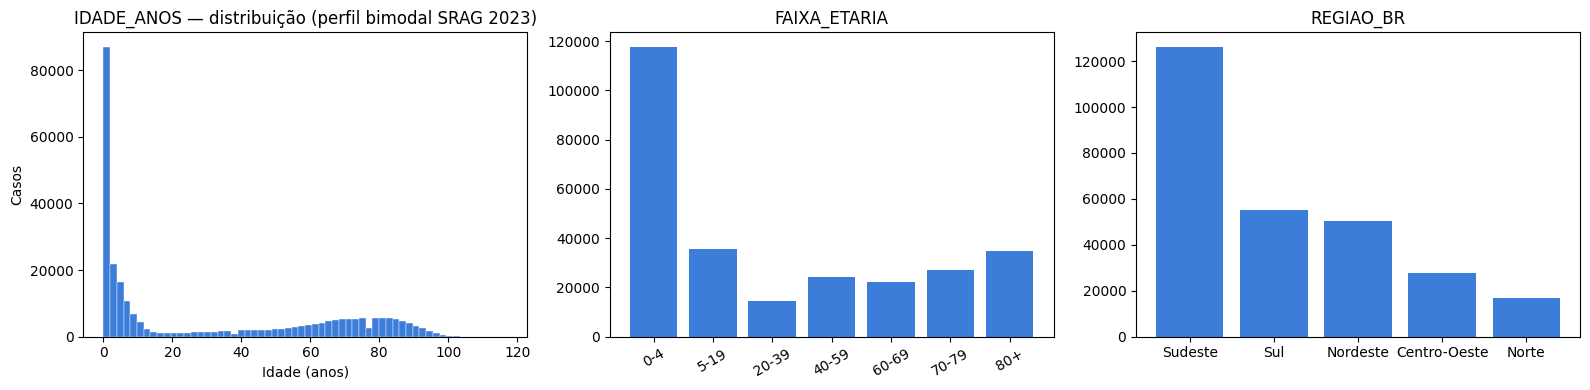

Salva: reports\figures\02_tratamento\01_demografia_pos_tratamento.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Idade
axes[0].hist(df['IDADE_ANOS'].dropna(), bins=60, color='#3b7dd8', edgecolor='white', linewidth=0.3)
axes[0].set_title('IDADE_ANOS — distribuição (perfil bimodal SRAG 2023)')
axes[0].set_xlabel('Idade (anos)')
axes[0].set_ylabel('Casos')

# Faixa etária
faixa = df['FAIXA_ETARIA'].value_counts().sort_index()
axes[1].bar(faixa.index.astype(str), faixa.values, color='#3b7dd8')
axes[1].set_title('FAIXA_ETARIA')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

# Região
regiao = df['REGIAO_BR'].value_counts()
axes[2].bar(regiao.index.astype(str), regiao.values, color='#3b7dd8')
axes[2].set_title('REGIAO_BR')
axes[2].set_xlabel('')

plt.tight_layout()
fig_path = FIG_DIR / "01_demografia_pos_tratamento.png"
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

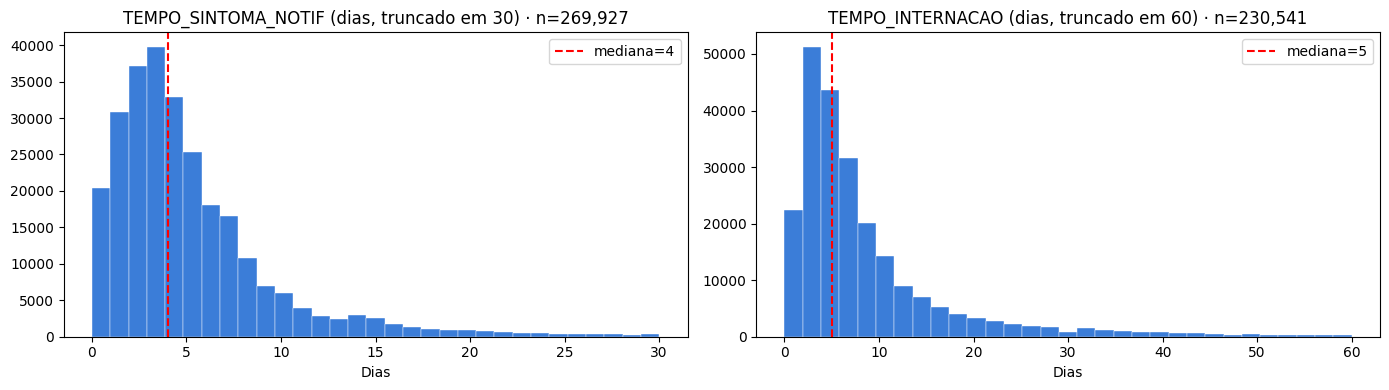

Salva: reports\figures\02_tratamento\02_tempos_clinicos.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Tempo sintoma → notificação (truncado para visualização)
ts = df['TEMPO_SINTOMA_NOTIF'].dropna()
ts_clip = ts[(ts >= 0) & (ts <= 30)]  # 99% < 30 dias; cauda longa atrapalha
axes[0].hist(ts_clip, bins=31, color='#3b7dd8', edgecolor='white', linewidth=0.3)
axes[0].set_title(f'TEMPO_SINTOMA_NOTIF (dias, truncado em 30) · n={len(ts_clip):,}')
axes[0].set_xlabel('Dias')
axes[0].axvline(ts.median(), color='red', linestyle='--', label=f'mediana={ts.median():.0f}')
axes[0].legend()

# Tempo de internação
ti = df['TEMPO_INTERNACAO'].dropna()
ti_clip = ti[(ti >= 0) & (ti <= 60)]
axes[1].hist(ti_clip, bins=31, color='#3b7dd8', edgecolor='white', linewidth=0.3)
axes[1].set_title(f'TEMPO_INTERNACAO (dias, truncado em 60) · n={len(ti_clip):,}')
axes[1].set_xlabel('Dias')
axes[1].axvline(ti.median(), color='red', linestyle='--', label=f'mediana={ti.median():.0f}')
axes[1].legend()

plt.tight_layout()
fig_path = FIG_DIR / "02_tempos_clinicos.png"
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Salva: {fig_path.relative_to(config.PROJECT_ROOT)}")

## 12. Sanity checks finais

Antes de persistir, são conferidos: shape, ausência de duplicatas críticas, dtypes coerentes e ranges esperados.

In [13]:
print("=== Sanity checks ===")
print(f"Shape final              : {df.shape[0]:,} × {df.shape[1]}")
print(f"DT_NOTIFIC range         : {df['DT_NOTIFIC'].min().date()} → {df['DT_NOTIFIC'].max().date()}")
print(f"Anos únicos              : {sorted(df['DT_NOTIFIC'].dt.year.unique().tolist())}")

# NU_NOTIFIC: chave do registro. Duplicatas indicam reabertura ou erro.
n_dup = df['NU_NOTIFIC'].duplicated().sum()
print(f"NU_NOTIFIC duplicados    : {n_dup:,} ({n_dup / len(df) * 100:.3f}%)")

# Target distribuição
target = pd.to_numeric(df['EVOLUCAO'], errors='coerce')
print(f"EVOLUCAO {{1,2}} (mod.)    : {target.isin([1, 2]).sum():,}")
print(f"  → taxa de óbito SRAG   : {(target == 2).sum() / target.isin([1, 2]).sum() * 100:.2f}%")

# Memória
mem_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Memória em RAM           : {mem_mb:.1f} MB")

=== Sanity checks ===
Shape final              : 276,339 × 185
DT_NOTIFIC range         : 2023-01-01 → 2023-12-31
Anos únicos              : [2023]
NU_NOTIFIC duplicados    : 0 (0.000%)
EVOLUCAO {1,2} (mod.)    : 248,479
  → taxa de óbito SRAG   : 9.84%
Memória em RAM           : 491.1 MB


## 13. Persistência — `data/interim/srag_2023_clean.parquet`

A persistência ocorre com o dataset completo, sem filtro pelo target. A Fase 3 (EDA) precisa de todos os 276 mil casos para descrever o cenário, incluindo `EVOLUCAO=3` e ignorados. O subset de modelagem (cerca de 248 mil linhas, com `EVOLUCAO ∈ {1, 2}`) é construído sob demanda na Fase 4 via `cleaning.clean_pipeline(filter_target=True)` ou diretamente `cleaning.filter_modeling_target(df_clean)`.

In [14]:
out_path = config.CLEAN_PARQUET_PATH
out_path.parent.mkdir(parents=True, exist_ok=True)

df.to_parquet(out_path, compression="zstd", index=False)

size_mb = out_path.stat().st_size / (1024 ** 2)
print(f"Escrito: {out_path.relative_to(config.PROJECT_ROOT)} ({size_mb:.1f} MB)")

# Re-leitura como sanity (prova que o arquivo é válido).
df_back = pd.read_parquet(out_path)
assert df_back.shape == df.shape, "Shape mudou no roundtrip!"
print(f"Round-trip OK: {df_back.shape[0]:,} × {df_back.shape[1]}")

Escrito: data\interim\srag_2023_clean.parquet (18.5 MB)
Round-trip OK: 276,339 × 185


## 14. Conclusão e handoff para a Fase 3

O que foi entregue:

- Pipeline de tratamento implementado em `src/maxpar_srag/cleaning.py` (10 funções), com 29 testes unitários em `tests/test_cleaning.py`, todos passando.
- Dataset limpo em `data/interim/srag_2023_clean.parquet` (cerca de 276 mil linhas e 185 colunas após drops, derivadas e labels).
- Figuras de QA em `reports/figures/02_tratamento/`.

As decisões registradas neste notebook, cada uma justificada acima:

1. Drop de 28 colunas mortas; manutenção das 5 quase-constantes para reavaliação na Fase 4.
2. Cast conservador (apenas se 100% parsearem), preservando colunas mistas.
3. Filtro temporal de 2023 aplicado, com 3.114 casos descartados.
4. `IDADE_ANOS` unificada com clip em `[0, 120]`; 7 valores aberrantes viraram NaN.
5. Binárias `{1, 2, 9}` para `{1, 0, NaN}`; `SUPORT_VEN` (3 valores) tratado como categórica.
6. `_LABEL` paralelas para 14 categóricas, preservando o código original.
7. Derivadas: `FAIXA_ETARIA`, `REGIAO_BR`, `TEMPO_SINTOMA_NOTIF` e `TEMPO_INTERNACAO`.
8. Imputação adiada para a Fase 4, dentro de pipeline ajustável apenas em treino.
9. Filtro do target adiado para preservar o universo completo na Fase 3.

Próximos passos (Fase 3 — EDA descritiva):

- Carregar `srag_2023_clean.parquet`.
- Responder cada item do enunciado: visão geral, sazonalidade, geografia, demografia, sintomatologia, comorbidades, vacinação COVID, cuidado hospitalar e mortalidade.
- Tudo já está tipado e documentado, de modo que a EDA não precisa repetir o tratamento.